In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
reviews = pd.read_csv(r"D:\Data Analyst\DA Project-2\Airbnb_Automated_Pipeline_Project\data\raw\Reviews.csv")

In [3]:
reviews.head()

,listing_id,review_id,date,reviewer_id
0,11798,330265172,2018-09-30,11863072
1,15383,330103585,2018-09-30,39147453
2,16455,329985788,2018-09-30,1125378
3,17919,330016899,2018-09-30,172717984
4,26827,329995638,2018-09-30,17542859


In [4]:
listings = pd.read_csv(r"D:\Data Analyst\DA Project-2\Airbnb_Automated_Pipeline_Project\data\raw\Listings.csv", encoding="latin1", low_memory=False)

In [5]:
pd.set_option('display.max_columns', None)
listings.head()

,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood,district,city,latitude,longitude,property_type,room_type,accommodates,bedrooms,amenities,price,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
0,281420,"Beautiful Flat in le Village Montmartre, Paris",1466919,2011-12-03,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,t,f,Buttes-Montmartre,NaN,Paris,48.88668,2.33343,Entire apartment,Entire place,2,1.0,"[""Heating"", ""Kitchen"", ""Washer"", ""Wifi"", ""Long...",53,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
1,3705183,39 mÃÂ² Paris (Sacre CÃ âur),10328771,2013-11-29,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,t,t,Buttes-Montmartre,NaN,Paris,48.88617,2.34515,Entire apartment,Entire place,2,1.0,"[""Shampoo"", ""Heating"", ""Kitchen"", ""Essentials""...",120,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
2,4082273,"Lovely apartment with Terrace, 60m2",19252768,2014-07-31,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,t,f,Elysee,NaN,Paris,48.88112,2.31712,Entire apartment,Entire place,2,1.0,"[""Heating"", ""TV"", ""Kitchen"", ""Washer"", ""Wifi"",...",89,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
3,4797344,Cosy studio (close to Eiffel tower),10668311,2013-12-17,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,t,t,Vaugirard,NaN,Paris,48.84571,2.30584,Entire apartment,Entire place,2,1.0,"[""Heating"", ""TV"", ""Kitchen"", ""Wifi"", ""Long ter...",58,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
4,4823489,Close to Eiffel Tower - Beautiful flat : 2 rooms,24837558,2014-12-14,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,t,f,Passy,NaN,Paris,48.85500,2.26979,Entire apartment,Entire place,2,1.0,"[""Heating"", ""TV"", ""Kitchen"", ""Essentials"", ""Ha...",60,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f


In [6]:
listings.shape

(279712, 33)

In [7]:
reviews.shape

(5373143, 4)

In [8]:
listings.columns

Index(['listing_id', 'name', 'host_id', 'host_since', 'host_location',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_total_listings_count',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'district', 'city', 'latitude', 'longitude', 'property_type',
       'room_type', 'accommodates', 'bedrooms', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'review_scores_rating',
       'review_scores_accuracy', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_communication',
       'review_scores_location', 'review_scores_value', 'instant_bookable'],
      dtype='str')

In [9]:
reviews.columns

Index(['listing_id', 'review_id', 'date', 'reviewer_id'], dtype='str')

In [10]:
listings.info()

<class 'pandas.DataFrame'>
RangeIndex: 279712 entries, 0 to 279711
Data columns (total 33 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   listing_id                   279712 non-null  int64  
 1   name                         279537 non-null  str    
 2   host_id                      279712 non-null  int64  
 3   host_since                   279547 non-null  str    
 4   host_location                278872 non-null  str    
 5   host_response_time           150930 non-null  str    
 6   host_response_rate           150930 non-null  float64
 7   host_acceptance_rate         166625 non-null  float64
 8   host_is_superhost            279547 non-null  str    
 9   host_total_listings_count    279547 non-null  float64
 10  host_has_profile_pic         279547 non-null  str    
 11  host_identity_verified       279547 non-null  str    
 12  neighbourhood                279712 non-null  str    
 13  district  

In [11]:
reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 5373143 entries, 0 to 5373142
Data columns (total 4 columns):
 #   Column       Dtype
---  ------       -----
 0   listing_id   int64
 1   review_id    int64
 2   date         str  
 3   reviewer_id  int64
dtypes: int64(3), str(1)
memory usage: 215.2 MB


In [12]:
listings.isnull().sum()

listing_id                          0
name                              175
host_id                             0
host_since                        165
host_location                     840
host_response_time             128782
host_response_rate             128782
host_acceptance_rate           113087
host_is_superhost                 165
host_total_listings_count         165
host_has_profile_pic              165
host_identity_verified            165
neighbourhood                       0
district                       242700
city                                0
latitude                            0
longitude                           0
property_type                       0
room_type                           0
accommodates                        0
bedrooms                        29435
amenities                           0
price                               0
minimum_nights                      0
maximum_nights                      0
review_scores_rating            91405
review_score

In [13]:
listings.isnull().mean()*100

listing_id                      0.000000
name                            0.062564
host_id                         0.000000
host_since                      0.058989
host_location                   0.300309
host_response_time             46.040928
host_response_rate             46.040928
host_acceptance_rate           40.429799
host_is_superhost               0.058989
host_total_listings_count       0.058989
host_has_profile_pic            0.058989
host_identity_verified          0.058989
neighbourhood                   0.000000
district                       86.767818
city                            0.000000
latitude                        0.000000
longitude                       0.000000
property_type                   0.000000
room_type                       0.000000
accommodates                    0.000000
bedrooms                       10.523324
amenities                       0.000000
price                           0.000000
minimum_nights                  0.000000
maximum_nights  

In [14]:
listings = listings.drop(columns=["district"])

In [15]:
listings.shape

(279712, 32)

In [16]:
listings["host_since"] = pd.to_datetime(listings["host_since"])

In [17]:
listings.info()

<class 'pandas.DataFrame'>
RangeIndex: 279712 entries, 0 to 279711
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   listing_id                   279712 non-null  int64         
 1   name                         279537 non-null  str           
 2   host_id                      279712 non-null  int64         
 3   host_since                   279547 non-null  datetime64[us]
 4   host_location                278872 non-null  str           
 5   host_response_time           150930 non-null  str           
 6   host_response_rate           150930 non-null  float64       
 7   host_acceptance_rate         166625 non-null  float64       
 8   host_is_superhost            279547 non-null  str           
 9   host_total_listings_count    279547 non-null  float64       
 10  host_has_profile_pic         279547 non-null  str           
 11  host_identity_verified       279547 n

In [18]:
listings["host_is_superhost"].unique()

<ArrowStringArray>
['f', 't', nan]
Length: 3, dtype: str

In [19]:
listings["host_has_profile_pic"].unique()

<ArrowStringArray>
['t', 'f', nan]
Length: 3, dtype: str

In [20]:
listings["host_identity_verified"].unique()

<ArrowStringArray>
['f', 't', nan]
Length: 3, dtype: str

In [21]:
listings["instant_bookable"].unique()

<ArrowStringArray>
['f', 't']
Length: 2, dtype: str

In [22]:
bool_cols = ['host_is_superhost', 'host_has_profile_pic', 'host_identity_verified', 'instant_bookable']
listings[bool_cols] = listings[bool_cols].replace({'t':True, 'f':False}).astype('boolean')
listings[bool_cols].head()

,host_is_superhost,host_has_profile_pic,host_identity_verified,instant_bookable
0,False,True,False,False
1,False,True,True,False
2,False,True,False,False
3,False,True,True,False
4,False,True,False,False


In [23]:
listings['host_is_superhost'].mean()

np.float64(0.17976583544090977)

In [24]:
listings.info()

<class 'pandas.DataFrame'>
RangeIndex: 279712 entries, 0 to 279711
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   listing_id                   279712 non-null  int64         
 1   name                         279537 non-null  str           
 2   host_id                      279712 non-null  int64         
 3   host_since                   279547 non-null  datetime64[us]
 4   host_location                278872 non-null  str           
 5   host_response_time           150930 non-null  str           
 6   host_response_rate           150930 non-null  float64       
 7   host_acceptance_rate         166625 non-null  float64       
 8   host_is_superhost            279547 non-null  boolean       
 9   host_total_listings_count    279547 non-null  float64       
 10  host_has_profile_pic         279547 non-null  boolean       
 11  host_identity_verified       279547 n

In [25]:
listings["bedrooms"].describe()

count    250277.000000
mean          1.515509
std           1.153080
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max          50.000000
Name: bedrooms, dtype: float64

In [26]:
listings["bedrooms"].isnull().sum()

np.int64(29435)

In [27]:
listings["bedrooms"] = listings["bedrooms"].fillna(listings["bedrooms"].median())

In [28]:
listings["bedrooms"].isnull().sum()

np.int64(0)

In [29]:
listings["bedrooms"].describe()

count    279712.000000
mean          1.461260
std           1.102133
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max          50.000000
Name: bedrooms, dtype: float64

In [30]:
review_cols = ['review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication',
    'review_scores_location', 'review_scores_value']
listings[review_cols] = listings[review_cols].fillna(listings[review_cols].median())

In [31]:
listings[review_cols].isnull().sum()

review_scores_rating           0
review_scores_accuracy         0
review_scores_cleanliness      0
review_scores_checkin          0
review_scores_communication    0
review_scores_location         0
review_scores_value            0
dtype: int64

In [32]:
listings["host_response_time"].value_counts()

host_response_time
within an hour        83464
within a few hours    28891
within a day          23425
a few days or more    15150
Name: count, dtype: int64

In [33]:
listings.groupby("host_is_superhost")["price"].mean()

host_is_superhost
False    596.730442
True     664.341691
Name: price, dtype: float64

In [34]:
listings["host_response_time"] = listings["host_response_time"].fillna("no response")

In [35]:
listings["host_response_time"].value_counts()

host_response_time
no response           128782
within an hour         83464
within a few hours     28891
within a day           23425
a few days or more     15150
Name: count, dtype: int64

In [36]:
listings["host_response_time"].isnull().sum()

np.int64(0)

In [37]:
listings[['host_response_rate','host_acceptance_rate']].describe()

,host_response_rate,host_acceptance_rate
count,150930.000000,166625.000000
mean,0.865939,0.827168
std,0.283744,0.289202
min,0.000000,0.000000
25%,0.900000,0.780000
50%,1.000000,0.980000
75%,1.000000,1.000000
max,1.000000,1.000000


In [38]:
listings["host_response_rate"] = listings["host_response_rate"].fillna(listings["host_response_rate"].median())
listings["host_acceptance_rate"] = listings["host_acceptance_rate"].fillna(listings["host_acceptance_rate"].median())

In [39]:
listings[["host_response_rate","host_acceptance_rate"]].isnull().sum()
# listings["host_acceptance_rate"].isnull().sum()

host_response_rate      0
host_acceptance_rate    0
dtype: int64

In [40]:
listings["amenities"].head()

0    ["Heating", "Kitchen", "Washer", "Wifi", "Long...
1    ["Shampoo", "Heating", "Kitchen", "Essentials"...
2    ["Heating", "TV", "Kitchen", "Washer", "Wifi",...
3    ["Heating", "TV", "Kitchen", "Wifi", "Long ter...
4    ["Heating", "TV", "Kitchen", "Essentials", "Ha...
Name: amenities, dtype: str

In [41]:
listings["amenities"].iloc[0]

'["Heating", "Kitchen", "Washer", "Wifi", "Long term stays allowed"]'

In [42]:
import ast
listings["amenities"] = listings["amenities"].apply(ast.literal_eval)

In [43]:
type(listings["amenities"].iloc[0])

list

In [44]:
listings.info()

<class 'pandas.DataFrame'>
RangeIndex: 279712 entries, 0 to 279711
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   listing_id                   279712 non-null  int64         
 1   name                         279537 non-null  str           
 2   host_id                      279712 non-null  int64         
 3   host_since                   279547 non-null  datetime64[us]
 4   host_location                278872 non-null  str           
 5   host_response_time           279712 non-null  str           
 6   host_response_rate           279712 non-null  float64       
 7   host_acceptance_rate         279712 non-null  float64       
 8   host_is_superhost            279547 non-null  boolean       
 9   host_total_listings_count    279547 non-null  float64       
 10  host_has_profile_pic         279547 non-null  boolean       
 11  host_identity_verified       279547 n

In [45]:
listings["listing_id"].duplicated().sum()

np.int64(0)

In [46]:
listings["bedrooms"].value_counts().sort_index()

bedrooms
1.0     199598
2.0      51382
3.0      18525
4.0       6579
5.0       2106
6.0        701
7.0        246
8.0        124
9.0         79
10.0       150
11.0        32
12.0        38
13.0         7
14.0        15
15.0        12
16.0        16
17.0         3
18.0         4
19.0         3
20.0        22
21.0         2
22.0         5
23.0         4
24.0         4
25.0         1
26.0         1
30.0         4
31.0         2
33.0         3
34.0         1
35.0         2
38.0         2
39.0         2
40.0        10
41.0         1
42.0         1
46.0         2
48.0         1
50.0        22
Name: count, dtype: int64

<Axes: ylabel='bedrooms'>

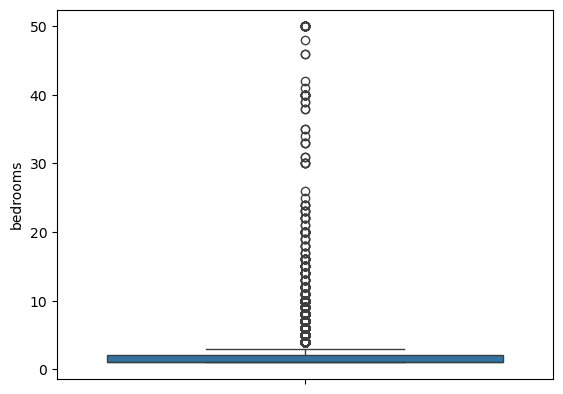

In [47]:
sns.boxplot(y=listings['bedrooms'])

<Axes: xlabel='bedrooms', ylabel='Count'>

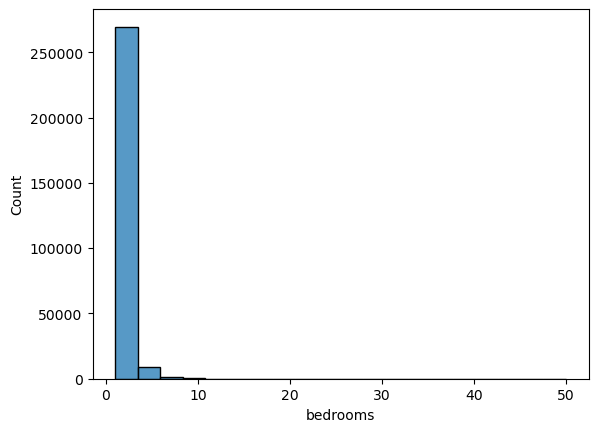

In [48]:
sns.histplot(listings['bedrooms'], bins=20)

In [49]:
listings = listings[listings["bedrooms"]<=10]

In [50]:
listings.shape

(279490, 32)

In [51]:
listings["price"].describe()

count    279490.000000
mean        606.510737
std        3427.978656
min           0.000000
25%          75.000000
50%         150.000000
75%         472.000000
max      625216.000000
Name: price, dtype: float64

<Axes: xlabel='price', ylabel='Count'>

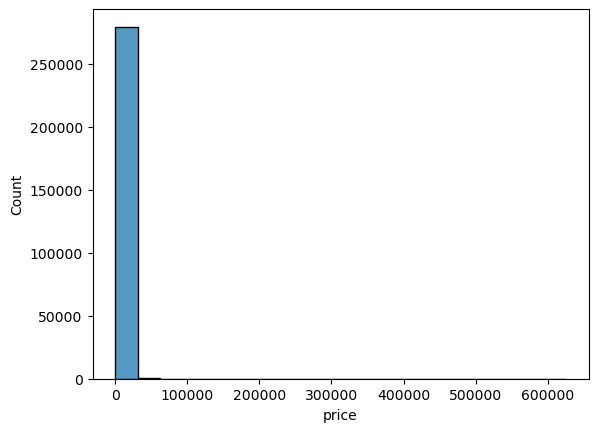

In [52]:
sns.histplot(listings["price"], bins=20)

<Axes: ylabel='price'>

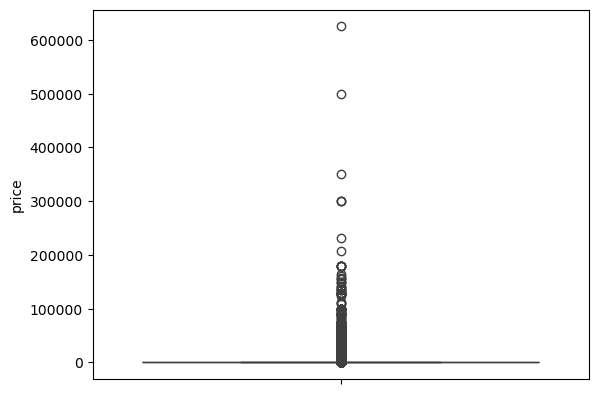

In [53]:
sns.boxplot(listings["price"])

In [54]:
listings[listings["price"]==0].shape

(113, 32)

In [55]:
Q1 = listings['price'].quantile(0.25)
Q3 = listings['price'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

lower_bound, upper_bound

(np.float64(-520.5), np.float64(1067.5))

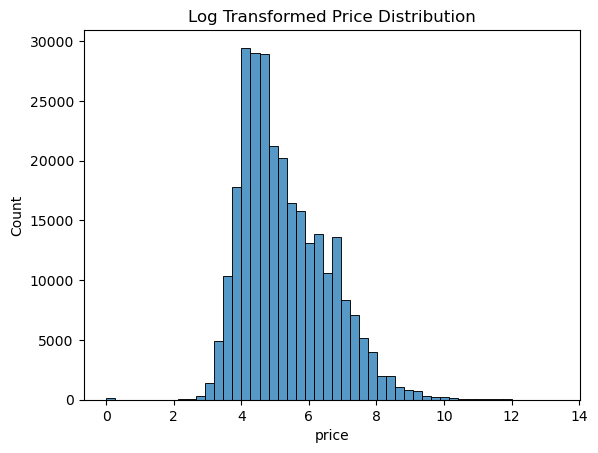

In [56]:
sns.histplot(np.log1p(listings['price']), bins=50)
plt.title("Log Transformed Price Distribution")
plt.show()

In [57]:
listings = listings[(listings["price"]>0) & (listings["price"]<= upper_bound)]

In [58]:
listings.shape

(247969, 32)

In [59]:
listings["price"].quantile([0.90, 0.95, 0.99, 0.999])

0.900     613.0
0.950     800.0
0.990    1000.0
0.999    1051.0
Name: price, dtype: float64

In [60]:
listings.info()

<class 'pandas.DataFrame'>
Index: 247969 entries, 0 to 279711
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   listing_id                   247969 non-null  int64         
 1   name                         247818 non-null  str           
 2   host_id                      247969 non-null  int64         
 3   host_since                   247826 non-null  datetime64[us]
 4   host_location                247284 non-null  str           
 5   host_response_time           247969 non-null  str           
 6   host_response_rate           247969 non-null  float64       
 7   host_acceptance_rate         247969 non-null  float64       
 8   host_is_superhost            247826 non-null  boolean       
 9   host_total_listings_count    247826 non-null  float64       
 10  host_has_profile_pic         247826 non-null  boolean       
 11  host_identity_verified       247826 non-nu

In [61]:
listings['host_location'] = listings['host_location'].fillna('Unknown')

listings['host_is_superhost'] = listings['host_is_superhost'].fillna(False)
listings['host_has_profile_pic'] = listings['host_has_profile_pic'].fillna(False)
listings['host_identity_verified'] = listings['host_identity_verified'].fillna(False)

listings['host_total_listings_count'] = listings['host_total_listings_count'].fillna(
    listings['host_total_listings_count'].median()
)

In [62]:
listings.info()

<class 'pandas.DataFrame'>
Index: 247969 entries, 0 to 279711
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   listing_id                   247969 non-null  int64         
 1   name                         247818 non-null  str           
 2   host_id                      247969 non-null  int64         
 3   host_since                   247826 non-null  datetime64[us]
 4   host_location                247969 non-null  str           
 5   host_response_time           247969 non-null  str           
 6   host_response_rate           247969 non-null  float64       
 7   host_acceptance_rate         247969 non-null  float64       
 8   host_is_superhost            247969 non-null  boolean       
 9   host_total_listings_count    247969 non-null  float64       
 10  host_has_profile_pic         247969 non-null  boolean       
 11  host_identity_verified       247969 non-nu

In [63]:
listings.isnull().sum()

listing_id                       0
name                           151
host_id                          0
host_since                     143
host_location                    0
host_response_time               0
host_response_rate               0
host_acceptance_rate             0
host_is_superhost                0
host_total_listings_count        0
host_has_profile_pic             0
host_identity_verified           0
neighbourhood                    0
city                             0
latitude                         0
longitude                        0
property_type                    0
room_type                        0
accommodates                     0
bedrooms                         0
amenities                        0
price                            0
minimum_nights                   0
maximum_nights                   0
review_scores_rating             0
review_scores_accuracy           0
review_scores_cleanliness        0
review_scores_checkin            0
review_scores_commun

In [64]:
listings["host_since"].isna().sum()

np.int64(143)

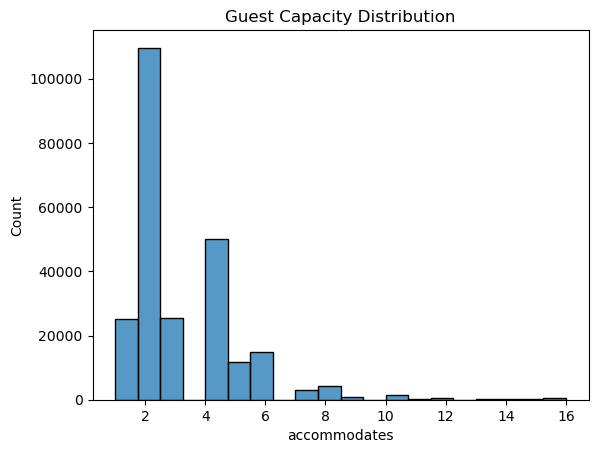

In [65]:
sns.histplot(listings["accommodates"], bins=20)
plt.title("Guest Capacity Distribution")
plt.show()

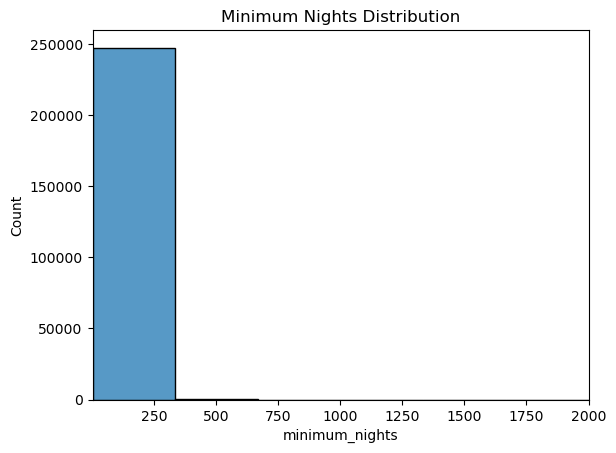

In [66]:
sns.histplot(listings['minimum_nights'], bins=30)
plt.title("Minimum Nights Distribution")
plt.xlim(1, 2000)
plt.show()

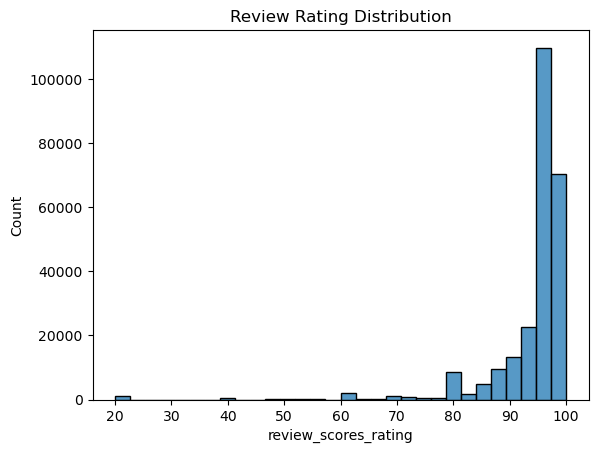

In [67]:
sns.histplot(listings['review_scores_rating'], bins=30)
plt.title("Review Rating Distribution")
plt.show()

In [68]:
listings["minimum_nights"].value_counts().head(20)

minimum_nights
1      79681
2      54697
3      34141
30     27791
5      12130
4      11630
7       9504
6       3183
10      2183
14      1938
28      1654
15      1448
29      1090
90       820
20       720
60       634
31       625
8        435
21       397
180      355
Name: count, dtype: int64

In [69]:
listings["room_type"].value_counts()

room_type
Entire place    158123
Private room     80544
Hotel room        4657
Shared room       4645
Name: count, dtype: int64

In [70]:
listings['property_type'].value_counts().head(20)

property_type
Entire apartment                      126914
Private room in apartment              45612
Private room in house                  12495
Entire condominium                      8535
Entire house                            8327
Room in boutique hotel                  4690
Entire loft                             4116
Private room in condominium             3913
Private room in bed and breakfast       3672
Entire serviced apartment               3036
Private room in townhouse               2730
Room in hotel                           2470
Shared room in apartment                2341
Entire guest suite                      2048
Entire townhouse                        1753
Private room in serviced apartment      1360
Room in aparthotel                      1294
Private room in guest suite             1235
Private room in guesthouse               973
Entire guesthouse                        948
Name: count, dtype: int64

In [71]:
listings['city'].value_counts()

city
Paris             64434
New York          36753
Sydney            32894
Rome              27527
Rio de Janeiro    23576
Istanbul          22953
Mexico City       14652
Cape Town          9523
Bangkok            9473
Hong Kong          6184
Name: count, dtype: int64

In [72]:
listings[['room_type','property_type','city']].nunique()

room_type          4
property_type    141
city              10
dtype: int64

In [73]:
listings["minimum_nights"].describe()

count    247969.000000
mean          8.213321
std          31.966366
min           1.000000
25%           1.000000
50%           2.000000
75%           5.000000
max        9999.000000
Name: minimum_nights, dtype: float64

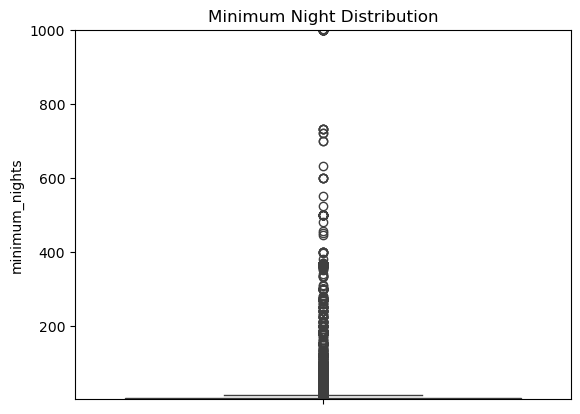

In [74]:
sns.boxplot(listings["minimum_nights"])
plt.title("Minimum Night Distribution")
plt.ylim(1,1000)
plt.show()

In [75]:
listings['maximum_nights'].describe()

count    2.479690e+05
mean     3.094929e+04
std      7.734958e+06
min      1.000000e+00
25%      3.500000e+01
50%      1.125000e+03
75%      1.125000e+03
max      2.147484e+09
Name: maximum_nights, dtype: float64

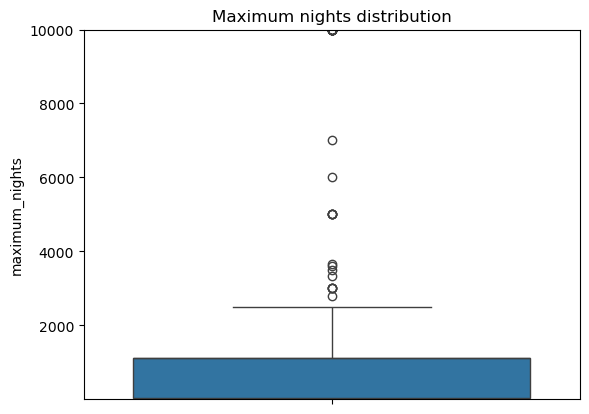

In [76]:
sns.boxplot(listings["maximum_nights"])
plt.title("Maximum nights distribution")
plt.ylim(1,10000)
plt.show()

In [77]:
listings[["latitude", "longitude"]].describe()

,latitude,longitude
count,247969.000000,247969.000000
mean,21.430150,11.202240
std,32.343369,72.784153
min,-34.246860,-99.339630
25%,-22.928950,-43.199140
50%,40.762950,2.371670
75%,48.830190,28.979870
max,48.904910,151.339770


In [78]:
reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 5373143 entries, 0 to 5373142
Data columns (total 4 columns):
 #   Column       Dtype
---  ------       -----
 0   listing_id   int64
 1   review_id    int64
 2   date         str  
 3   reviewer_id  int64
dtypes: int64(3), str(1)
memory usage: 215.2 MB


In [79]:
reviews.isnull().sum()

listing_id     0
review_id      0
date           0
reviewer_id    0
dtype: int64

In [80]:
reviews["date"] = pd.to_datetime(reviews["date"])
reviews["date"].describe()

count                       5373143
mean     2018-06-26 06:57:54.259291
min             2008-11-16 00:00:00
25%             2017-07-04 00:00:00
50%             2018-10-29 00:00:00
75%             2019-09-21 00:00:00
max             2021-03-01 00:00:00
Name: date, dtype: object

In [81]:
reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 5373143 entries, 0 to 5373142
Data columns (total 4 columns):
 #   Column       Dtype         
---  ------       -----         
 0   listing_id   int64         
 1   review_id    int64         
 2   date         datetime64[us]
 3   reviewer_id  int64         
dtypes: datetime64[us](1), int64(3)
memory usage: 164.0 MB


C:\Users\Intelb\AppData\Local\Temp\ipykernel_14884\442565129.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="room_type", y="price", data=listings, palette="viridis")


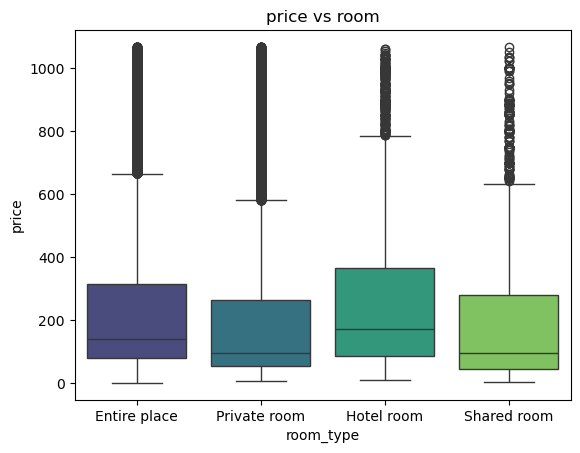

In [82]:
sns.boxplot(x="room_type", y="price", data=listings, palette="viridis")
plt.title("price vs room")
plt.show()

In [94]:
listings_clean = listings.copy()
listings_clean.head()
listings_clean.shape
listings_clean.info()
listings_clean.isnull().sum()
listings_clean["listing_id"].duplicated().sum()
listings_clean.describe()

<class 'pandas.DataFrame'>
Index: 247969 entries, 0 to 279711
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   listing_id                   247969 non-null  int64         
 1   name                         247818 non-null  str           
 2   host_id                      247969 non-null  int64         
 3   host_since                   247826 non-null  datetime64[us]
 4   host_location                247969 non-null  str           
 5   host_response_time           247969 non-null  str           
 6   host_response_rate           247969 non-null  float64       
 7   host_acceptance_rate         247969 non-null  float64       
 8   host_is_superhost            247969 non-null  boolean       
 9   host_total_listings_count    247969 non-null  float64       
 10  host_has_profile_pic         247969 non-null  boolean       
 11  host_identity_verified       247969 non-nu

,listing_id,host_id,host_since,host_response_rate,host_acceptance_rate,host_total_listings_count,latitude,longitude,accommodates,bedrooms,price,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
count,2.479690e+05,2.479690e+05,247826,247969.000000,247969.000000,247969.000000,247969.000000,247969.000000,247969.00000,247969.000000,247969.000000,247969.000000,2.479690e+05,247969.000000,247969.000000,247969.000000,247969.000000,247969.000000,247969.000000,247969.000000
mean,2.626108e+07,1.070320e+08,2016-03-28 17:15:20.591059,0.928854,0.889614,22.687949,21.430150,11.202240,3.09187,1.356161,232.259420,8.213321,3.094929e+04,94.135985,9.699184,9.514129,9.794313,9.792869,9.747436,9.539132
min,2.577000e+03,1.822000e+03,2008-08-12 00:00:00,0.000000,0.000000,0.000000,-34.246860,-99.339630,1.00000,1.000000,1.000000,1.000000,1.000000e+00,20.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
25%,1.363080e+07,1.643014e+07,2014-06-11 00:00:00,1.000000,0.950000,1.000000,-22.928950,-43.199140,2.00000,1.000000,70.000000,1.000000,3.500000e+01,94.000000,10.000000,9.000000,10.000000,10.000000,10.000000,9.000000
50%,2.748382e+07,5.633361e+07,2016-01-28 00:00:00,1.000000,0.980000,1.000000,40.762950,2.371670,2.00000,1.000000,125.000000,2.000000,1.125000e+03,96.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
75%,3.977338e+07,1.813873e+08,2018-03-31 00:00:00,1.000000,1.000000,4.000000,48.830190,28.979870,4.00000,1.000000,300.000000,5.000000,1.125000e+03,98.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
max,4.833988e+07,3.901874e+08,2021-02-26 00:00:00,1.000000,1.000000,7235.000000,48.904910,151.339770,16.00000,10.000000,1067.000000,9999.000000,2.147484e+09,100.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
std,1.451084e+07,1.110761e+08,NaN,0.217085,0.234632,264.033011,32.343369,72.784153,1.88565,0.744316,241.002312,31.966366,7.734958e+06,8.465772,0.844983,1.013043,0.730036,0.745809,0.709056,0.917899


In [96]:
listings_clean.to_csv(r"D:\Data Analyst\DA Project-2\Airbnb_Automated_Pipeline_Project\data\processed\clean_listings.csv", index=False)

### Data Profiling Summary

• Dataset contains ~248k Airbnb listings across multiple US cities.

• Price distribution is heavily right-skewed; extreme outliers above ~$1067 were removed using the IQR method.

• Majority of listings contain 1–2 bedrooms.

• Entire home/apartment is the dominant room type.

• Missing values were minimal (<1%) and handled appropriately.

• Review dataset contains over 5 million records representing user interactions.

• No duplicate listing IDs detected.

• Geographic coordinates fall within expected US ranges.